# Research Question 3: Spatial Distribution of Reports in 2025

## Research Question

Which Zurich Quartiere had the highest number of ZüriWieNeu reports in 2025?

## Goal of this notebook

The goal of this notebook is to analyse the spatial distribution of ZüriWieNeu reports across Zurich's Quartiere for the year 2025.

While the first two research questions focused on temporal changes and category composition, this notebook adds a spatial perspective. Individual reports are point-based observations, meaning that each report has a specific location. By connecting these point locations to neighborhood polygons, reports can be aggregated to the Quartier level.

## Why this question is relevant

Aggregating reports by Quartier makes it possible to compare reporting activity across different neighborhoods of Zurich. This helps identify areas with particularly high or low numbers of reported urban infrastructure issues.

However, differences between Quartiere should be interpreted carefully. A high number of reports may reflect more infrastructure issues, but it may also be influenced by population density, land use, visitor activity, or differences in reporting behavior.

## Planned analysis

In this notebook, I will:

1. Load and clean the ZüriWieNeu report data.
2. Filter the reports to the year 2025.
3. Convert the report coordinates into a GeoDataFrame.
4. Load the Zurich Quartiere polygon shapefile.
5. Perform a spatial join between reports and Quartiere.
6. Count the number of reports per Quartier.
7. Visualize the result as a choropleth map.
8. Interpret the spatial pattern.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.loading import load_csv_data
from src.cleaning import clean_reports


In [2]:
quartiere = gpd.read_file(
    "/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/StatQuartiere_ZH"
)

quartiere.head()

/Users/laumagoldmann/miniconda3/envs/sds-env/lib/python3.14/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'StatQuartiere_ZH': 'stzh.adm_statistische_quartiere_v' (default), 'stzh.adm_statistische_quartiere_b_p', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [3]:
quartiere.columns

Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='str')

In [4]:
quartiere.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [6]:
from src.spatial import reports_to_geodataframe

df_raw = load_csv_data("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/stzh.zwn_meldungen_p.csv")
df_clean = clean_reports(df_raw)

df_2025 = df_clean[df_clean["year"] == 2025].copy()

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_gdf.head()

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry,year,month,year_month
44670,62831,70201,2025-06-16 20:06:53,2025-06-17 07:07:04,2025-06-17 07:07:04,2682447,1247655,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Veloschrott,https://www.zueriwieneu.ch/photo/70201.0.jpeg?...,desktop,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Veloschrott: Veloschrott,https://www.zueriwieneu.ch/report/70201,POINT (2682447 1247655),2025,6,2025-06-01
45845,61418,68672,2025-05-12 10:05:31,2025-05-12 10:12:05,2025-05-12 10:12:05,2681227,1248047,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Demoliertes Velo,https://www.zueriwieneu.ch/photo/68672.0.jpeg?...,Android,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Demoliertes: Demoliertes Velo,https://www.zueriwieneu.ch/report/68672,POINT (2681227 1248047),2025,5,2025-05-01
45867,61844,69139,2025-05-22 19:41:18,2025-05-22 19:42:05,2025-05-26 05:42:43,2682870,1247836,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,...,Lampe kaputt,NaN,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,Lampe kaput: Lampe kaputt,https://www.zueriwieneu.ch/report/69139,POINT (2682870 1247836),2025,5,2025-05-01
45975,63320,70728,2025-06-29 18:24:09,2025-06-30 12:12:04,2025-06-30 12:12:04,2681519,1247334,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/photo/70728.0.jpeg?...,iOS,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Ausgeschlac: Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/report/70728,POINT (2681519 1247334),2025,6,2025-06-01
46705,58911,65900,2025-02-16 22:19:45,2025-03-31 09:57:05,2025-04-03 10:26:13,2683763,1247000,Graffiti,Graffiti,fixed - council,...,Graffiti,NaN,Android,Besten Dank für Ihre Meldung auf «Züri wie neu...,Graffiti: Graffiti,https://www.zueriwieneu.ch/report/65900,POINT (2683763 1247000),2025,2,2025-02-01


In [7]:
reports_2025_gdf.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [8]:
import importlib
import src.spatial

importlib.reload(src.spatial)

from src.spatial import reports_to_geodataframe, join_reports_to_quartiere

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_joined = join_reports_to_quartiere(
    reports_2025_gdf,
    quartiere
)

reports_2025_joined[["service_request_id", "qname", "qnr", "kname", "knr"]].head()

,service_request_id,qname,qnr,kname,knr
44670,70201,Langstrasse,42,Kreis 4,4
45845,68672,Hard,44,Kreis 4,4
45867,69139,City,14,Kreis 1,1
45975,70728,Sihlfeld,34,Kreis 3,3
46705,65900,Hochschulen,12,Kreis 1,1


In [9]:
reports_2025_joined["qname"].isna().sum()

np.int64(0)

The spatial join successfully assigned all 2025 reports to a Zurich Quartier. No reports had missing Quartier information after the join.

In [16]:
reports_by_quartier = (
    reports_2025_joined
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

reports_by_quartier.head(10)


,qname,report_count
16,Langstrasse,1200
27,Sihlfeld,795
3,Altstetten,628
31,Wipkingen,528
28,Unterstrass,517
10,Hard,470
25,Seebach,464
2,Alt-Wiedikon,456
21,Oerlikon,453
15,Höngg,417


## Reports by Quartier in 2025

The table above shows the ten Zurich Quartiere with the highest number of ZüriWieNeu reports in 2025.

The Quartier with the highest number of reports is **Langstrasse**, with 1,200 reports. It is followed by **Sihlfeld**, **Altstetten**, **Wipkingen**, and **Unterstrass**.

This indicates that reporting activity was not evenly distributed across Zurich's Quartiere in 2025. Some neighbourhoods generated substantially more reports than others. However, these differences should be interpreted carefully. A higher number of reports may reflect more infrastructure issues, but it may also be influenced by population density, centrality, visitor

In [17]:
quartiere_reports = quartiere.merge(
    reports_by_quartier,
    on="qname",
    how="left"
)

quartiere_reports["report_count"] = quartiere_reports["report_count"].fillna(0)

quartiere_reports[["qname", "report_count"]].sort_values(
    "report_count",
    ascending=False
).head(10)

,qname,report_count
2,Langstrasse,1200
17,Sihlfeld,795
28,Altstetten,628
21,Wipkingen,528
23,Unterstrass,517
29,Hard,470
32,Seebach,464
0,Alt-Wiedikon,456
19,Oerlikon,453
20,Höngg,417


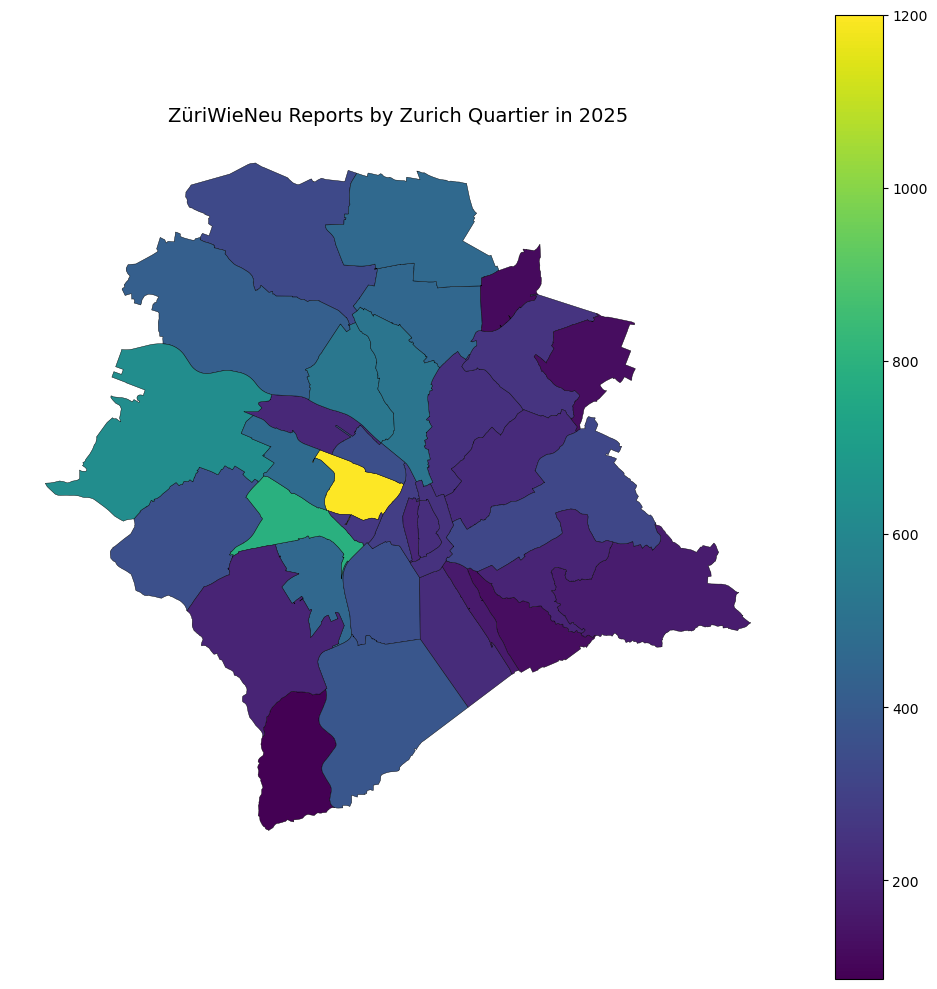

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

quartiere_reports.plot(
    column="report_count",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "ZüriWieNeu Reports by Zurich Quartier in 2025",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()


## Interpretation of the choropleth map

The choropleth map shows the number of ZüriWieNeu reports per Zurich Quartier in 2025.

The spatial pattern confirms that reporting activity was unevenly distributed across the city. Some Quartiere show clearly higher report counts than others. In particular, **Langstrasse** stands out as the Quartier with the highest number of reports in 2025, followed by areas such as **Sihlfeld**, **Altstetten**, **Wipkingen**, and **Unterstrass**.

This concentration of reports may be related to several factors. Quartiere with high report counts may have more infrastructure issues, but they may also have higher population density, more pedestrian activity, more nightlife or commercial activity, or simply more residents and visitors who use the reporting platform.

Therefore, the map should be interpreted as a visualization of reporting activity, not as a direct measurement of infrastructure quality.